<a href="https://colab.research.google.com/github/santana-robledo/Posgrado_Robotica_e_Inteligencia_Artificial/blob/main/Sistemas%20Inteligentes%20II/weatherHistory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Josue Santana Robledo Corona

In [94]:
# Paquetería básica
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Importamos Tensorflow y Keras
import tensorflow as tf
from tensorflow import keras

# Usamos funcionalidades básicas de Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [95]:
!wget https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/weatherHistory.csv

--2026-03-09 19:16:51--  https://raw.githubusercontent.com/Dr-Carlos-Villasenor/Clase_Aprendizaje_Profundo/main/Datasets/weatherHistory.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 16294377 (16M) [text/plain]
Saving to: ‘weatherHistory.csv.6’

weatherHistory.csv. 100%[===================>]  15.54M  --.-KB/s    in 0.1s    

2026-03-09 19:16:51 (135 MB/s) - ‘weatherHistory.csv.6’ saved [16294377/16294377]



In [96]:
dataset=pd.read_csv("weatherHistory.csv")
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [97]:
dataset.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [98]:
np.array(dataset['Precip Type'])

array(['rain', 'rain', 'rain', ..., 'rain', 'rain', 'rain'], dtype=object)

In [99]:
dataset['Precip Type'].unique()

array(['rain', 'snow', nan], dtype=object)

In [100]:
dataset = dataset.dropna()

In [101]:
dataset.isna().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [102]:
x = np.asanyarray(dataset.drop(columns=['Formatted Date','Summary','Precip Type','Daily Summary','Visibility (km)']))
y = np.asanyarray(dataset['Visibility (km)'])

x = StandardScaler().fit_transform(x)
print(x.shape)
print(y.shape)

(95936, 7)
(95936,)


In [103]:
xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2)

In [104]:
def build_model():

  model = keras.Sequential()
  model.add(keras.layers.Dense(16, activation='relu', input_shape=[x.shape[1]]))
  model.add(keras.layers.Dropout(0.2))
  model.add(keras.layers.Dense(8, activation='relu'))
  model.add(keras.layers.Dense(8, activation='relu'))
  model.add(keras.layers.Dense(1, activation='linear'))

  model.compile(loss='mean_squared_error',
                optimizer=keras.optimizers.Adam(),
                metrics=[keras.metrics.MAE, keras.metrics.R2Score])
  return  model

In [105]:
model = build_model()
model.summary()

result = model.evaluate(xtest, ytest)
print(result)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345 (1.35 KB)

 Trainable params: 345 (1.35 KB)

 Non-trainable params: 0 (0.00 B)

600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 121.1031 - mean_absolute_error: 10.1624 - r2_score: -5.9315
[122.15828704833984, 10.214735984802246, -5.993166923522949]


In [106]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch
  plt.figure()
  plt.subplot(121)
  plt.title('Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_loss'],
           label = 'Val')
  plt.yscale('log')
  plt.legend()

  plt.subplot(122)
  plt.title('R2 Score')
  plt.xlabel('Epoch')
  plt.ylabel('r2score')
  plt.plot(hist['epoch'], hist['r2_score'],
           label='Train')
  plt.plot(hist['epoch'], hist['val_r2_score'],
           label = 'Val')
  plt.ylim([0,1])
  plt.legend()


In [107]:
history = model.fit(xtrain, ytrain,
                    batch_size=150, epochs=250,
                    validation_data=(xtest, ytest), verbose=1)


Epoch 1/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 69.1680 - mean_absolute_error: 7.0172 - r2_score: -3.0146 - val_loss: 15.6552 - val_mean_absolute_error: 3.2244 - val_r2_score: 0.1038
Epoch 2/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 17.0436 - mean_absolute_error: 3.3638 - r2_score: 0.0211 - val_loss: 12.9083 - val_mean_absolute_error: 2.9252 - val_r2_score: 0.2610
Epoch 3/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 14.4545 - mean_absolute_error: 3.1120 - r2_score: 0.1721 - val_loss: 12.0583 - val_mean_absolute_error: 2.8151 - val_r2_score: 0.3097
Epoch 4/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 12.9195 - mean_absolute_error: 2.9492 - r2_score: 0.2597 - val_loss: 11.1859 - val_mean_absolute_error: 2.7906 - val_r2_score: 0.3596
Epoch 5/250
512/512 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 11.5794 - mean_absolute_error: 2.7994 - r2_score: 0.3356 - val_loss: 10.3153 - val_mean_absolute_error: 2.6482 - val_r2_score: 0.4095
Epoch 6/250
512/512 ━━━━

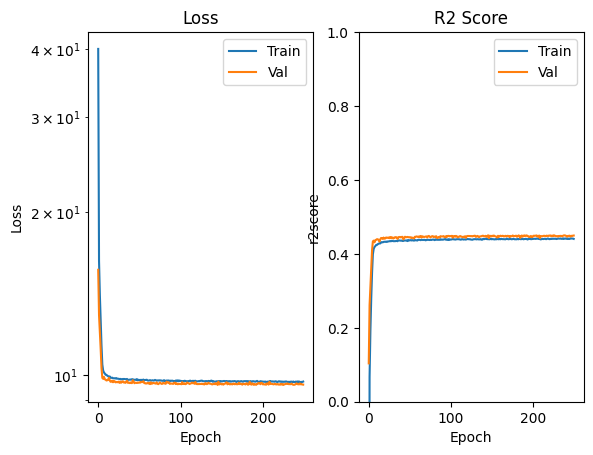

In [108]:
plot_history(history)

In [111]:
gist_df=pd.DataFrame(history.history)
##gist_df.to_csv('history.csv',index=False)
print(gist_df)

          loss  mean_absolute_error  r2_score   val_loss  \
0    39.998631             5.059663 -1.297696  15.655169   
1    16.243757             3.284914  0.066885  12.908346   
2    14.078752             3.071393  0.191245  12.058329   
3    12.550796             2.908081  0.279032  11.185909   
4    11.351935             2.781085  0.347892  10.315340   
..         ...                  ...       ...        ...   
245   9.720971             2.593171  0.441580   9.663446   
246   9.717227             2.593545  0.441801   9.625973   
247   9.724723             2.594212  0.441370   9.638241   
248   9.722393             2.594027  0.441502   9.618022   
249   9.738598             2.595212  0.440572   9.613563   

     val_mean_absolute_error  val_r2_score  
0                   3.224427      0.103788  
1                   2.925178      0.261035  
2                   2.815106      0.309696  
3                   2.790620      0.359640  
4                   2.648164      0.409477  
..       

In [112]:
result = model.evaluate(xtest, ytest)
print(result)

600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 9.6194 - mean_absolute_error: 2.5883 - r2_score: 0.4495
[9.613564491271973, 2.593015432357788, 0.4496545195579529]
